In [107]:
# %%
# FAIRNESS SIMULATOR NOTEBOOK (VERSION A)
# ---------------------------------------
# Goal:
#  - Simulate a fair world (no gender bias)
#  - Simulate a biased world (measurement bias for women)
#  - Train the same model in both
#  - Compare FPR, TPR, and Equalized Odds across genders


In [108]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

np.random.seed(42)  # reproducibility

In [122]:
import numpy as np
import pandas as pd

# Sigmoid for smooth probability boundary
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def simulate_fair_world(n_samples=20000):
    gender = np.random.binomial(1, 0.5, size=n_samples)

    hba1c = np.random.normal(loc=5.8, scale=0.9, size=n_samples)

    glucose_true = 18 * hba1c + np.random.normal(0, 12, size=n_samples)

    # Fuzzy diabetes boundary, not deterministic
    prob_diabetes = sigmoid(1.5*(hba1c - 6.5))
    diabetes_true = np.random.binomial(1, prob_diabetes)

    # More noise → produces realistic false positives
    glucose_measured = glucose_true + np.random.normal(0, 25, size=n_samples)

    return pd.DataFrame({
        "gender": gender,
        "hba1c": hba1c,
        "glucose_true": glucose_true,
        "glucose_measured": glucose_measured,
        "diabetes_true": diabetes_true
    })

def simulate_biased_world(n_samples=20000, bias_shift=20):
    df = simulate_fair_world(n_samples)
    df.loc[df["gender"] == 1, "glucose_measured"] += bias_shift
    return df


In [123]:
# %%
# HELPER: SIMULATE BIASED WORLD
# -----------------------------
# Same as fair world, but
# - For women (gender==1) we artificially add a positive bias to
#   measured glucose (e.g. +15 mg/dL).
#
# This makes women look "more diabetic" than they really are,
# increasing FALSE POSITIVES for women.


def simulate_biased_world(n_samples=20000, bias_shift=15.0):
    data = simulate_fair_world(n_samples)

    # Add measurement bias to measured glucose for women (gender==1)
    female_mask = (data["gender"] == 1)
    data.loc[female_mask, "glucose_measured"] += bias_shift

    return data

In [124]:
# %%
# HELPER: TRAIN LOGISTIC REGRESSION
# ---------------------------------
# Features:
#   - glucose_measured
#   - hba1c
# Target:
#   - diabetes_true
#
# Returns: trained model + test split

def train_logistic_model(df):
    X = df[["glucose_measured", "hba1c"]].values
    y = df["diabetes_true"].values
    g = df["gender"].values

    X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
        X, y, g, test_size=0.3, random_state=0, stratify=y
    )

    clf = LogisticRegression(solver="lbfgs", max_iter=1000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    return clf, X_test, y_test, g_test, y_pred

In [125]:
# %%
# 4. COMPUTE GROUP RATES & EQUALIZED ODDS
# --------------------------------------
# For each gender (0/1), we compute:
#   - TPR = TP / (TP + FN)
#   - FPR = FP / (FP + TN)
# Equalized Odds difference = |TPR_male - TPR_female| + |FPR_male - FPR_female|

def compute_group_rates_and_eo(y_true, y_pred, gender):
    groups = [0, 1]  # 0 = male, 1 = female
    metrics = {}

    for g in groups:
        mask = (gender == g)
        yt = y_true[mask]
        yp = y_pred[mask]

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        metrics[g] = {
            "TPR": tpr,
            "FPR": fpr,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        }

    # Equalized Odds difference (assumes only 2 groups: 0, 1)
    tpr_diff = abs(metrics[0]["TPR"] - metrics[1]["TPR"])
    fpr_diff = abs(metrics[0]["FPR"] - metrics[1]["FPR"])
    eo_diff = tpr_diff + fpr_diff

    return metrics, eo_diff

In [126]:
# %%
# 5. RUN SIMULATION: FAIR WORLD
# -----------------------------

fair_data = simulate_fair_world(n_samples=20000)
clf_fair, X_test_fair, y_test_fair, g_test_fair, y_pred_fair = train_logistic_model(fair_data)
metrics_fair, eo_fair = compute_group_rates_and_eo(y_test_fair, y_pred_fair, g_test_fair)

print("=== FAIR WORLD ===")
for g, m in metrics_fair.items():
    group_name = "Male" if g == 0 else "Female"
    print(f"{group_name}: TPR={m['TPR']:.3f}, FPR={m['FPR']:.3f}")
print(f"Equalized Odds difference (fair world): {eo_fair:.3f}")


=== FAIR WORLD ===
Male: TPR=0.454, FPR=0.095
Female: TPR=0.468, FPR=0.095
Equalized Odds difference (fair world): 0.014


In [127]:
# %%
# 6. RUN SIMULATION: BIASED WORLD
# -------------------------------

biased_data = simulate_biased_world(n_samples=20000, bias_shift=15.0)
clf_biased, X_test_biased, y_test_biased, g_test_biased, y_pred_biased = train_logistic_model(biased_data)
metrics_biased, eo_biased = compute_group_rates_and_eo(y_test_biased, y_pred_biased, g_test_biased)

print("\n=== BIASED WORLD ===")
for g, m in metrics_biased.items():
    group_name = "Male" if g == 0 else "Female"
    print(f"{group_name}: TPR={m['TPR']:.3f}, FPR={m['FPR']:.3f}")
print(f"Equalized Odds difference (biased world): {eo_biased:.3f}")



=== BIASED WORLD ===
Male: TPR=0.479, FPR=0.096
Female: TPR=0.485, FPR=0.105
Equalized Odds difference (biased world): 0.015


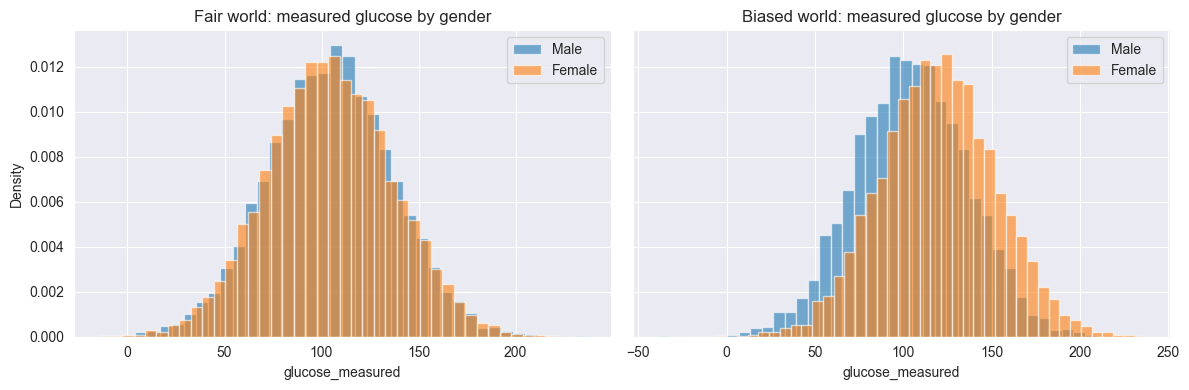

In [128]:
# %%
# 7. VISUALIZE GLUCOSE DISTRIBUTIONS BY GENDER
# -------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Fair world
for g, label, color in [(0, "Male", "tab:blue"), (1, "Female", "tab:orange")]:
    mask = (fair_data["gender"] == g)
    axes[0].hist(
        fair_data.loc[mask, "glucose_measured"],
        bins=40, density=True, alpha=0.6, label=label
    )
axes[0].set_title("Fair world: measured glucose by gender")
axes[0].set_xlabel("glucose_measured")
axes[0].set_ylabel("Density")
axes[0].legend()

# Biased world
for g, label, color in [(0, "Male", "tab:blue"), (1, "Female", "tab:orange")]:
    mask = (biased_data["gender"] == g)
    axes[1].hist(
        biased_data.loc[mask, "glucose_measured"],
        bins=40, density=True, alpha=0.6, label=label
    )
axes[1].set_title("Biased world: measured glucose by gender")
axes[1].set_xlabel("glucose_measured")
axes[1].legend()

plt.tight_layout()
plt.show()

In [129]:
# %%
# 8. SUMMARY TABLE (FOR REPORT)
# -----------------------------

summary_rows = []

for world_label, metrics, eo in [
    ("Fair world", metrics_fair, eo_fair),
    ("Biased world", metrics_biased, eo_biased),
]:
    for g in [0, 1]:
        summary_rows.append({
            "World": world_label,
            "Group": "Male" if g == 0 else "Female",
            "TPR": metrics[g]["TPR"],
            "FPR": metrics[g]["FPR"],
            "Equalized_Odds_diff_world": eo
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

# Optional: nice pivot for plotting
pivot_tpr = summary_df.pivot(index="World", columns="Group", values="TPR")
pivot_fpr = summary_df.pivot(index="World", columns="Group", values="FPR")

print("\nTPR by world and group:")
print(pivot_tpr)

print("\nFPR by world and group:")
print(pivot_fpr)

          World   Group       TPR       FPR  Equalized_Odds_diff_world
0    Fair world    Male  0.454450  0.094561                   0.013744
1    Fair world  Female  0.467656  0.095099                   0.013744
2  Biased world    Male  0.479036  0.096117                   0.015181
3  Biased world  Female  0.485149  0.105185                   0.015181

TPR by world and group:
Group           Female      Male
World                           
Biased world  0.485149  0.479036
Fair world    0.467656  0.454450

FPR by world and group:
Group           Female      Male
World                           
Biased world  0.105185  0.096117
Fair world    0.095099  0.094561


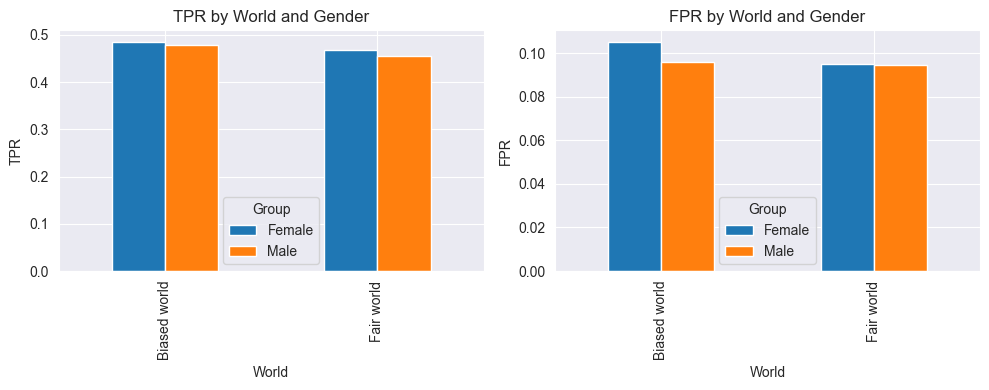

In [130]:
# %%
# 9. QUICK BAR PLOTS OF TPR/FPR DIFFERENCES
# -----------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pivot_tpr.plot(kind="bar", ax=axes[0])
axes[0].set_title("TPR by World and Gender")
axes[0].set_ylabel("TPR")

pivot_fpr.plot(kind="bar", ax=axes[1])
axes[1].set_title("FPR by World and Gender")
axes[1].set_ylabel("FPR")

plt.tight_layout()
plt.show()